# SESSION: Time-domain analyses #4.38. Event-related potential (ERP)

COURSE: Neural signal processing and analysis: Zero to hero

TEACHER: Mike X Cohen, sincxpress.com

**Goal:** Investigate the theory of an ERP via simulation

In [87]:
# Remember to always import first!
import sys
sys.path.insert(1, '../') #used to so that we can find our custom utils library later

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from utils import *

In [88]:
# simulation details
srate = 500
tmin = -1
tmax = 2
time = np.linspace(tmin,tmax,num=srate*(tmax - tmin))
ntrials = 100
sfreq = 9 #sine wave frequency in Hz
gpeakt = .43 #peak time of the gaussian in seconds
gwidth = .2 #width of the gaussian in seconds

noiseamp = 2 # std. deviation of the noise

rng = np.random.default_rng() # random number generator

First, create the signal.

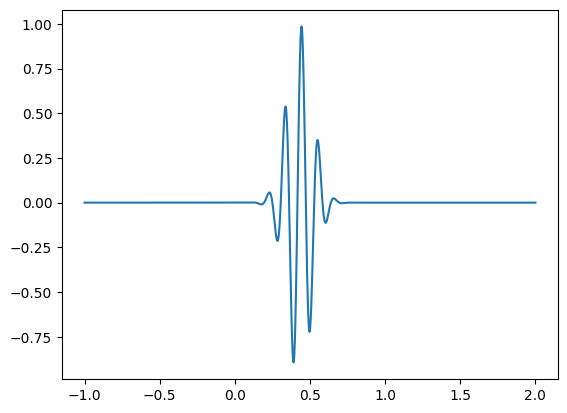

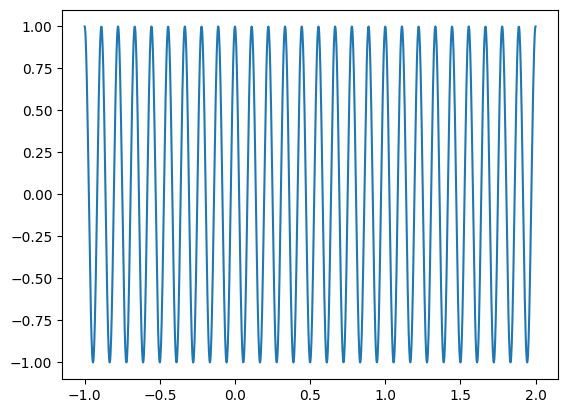

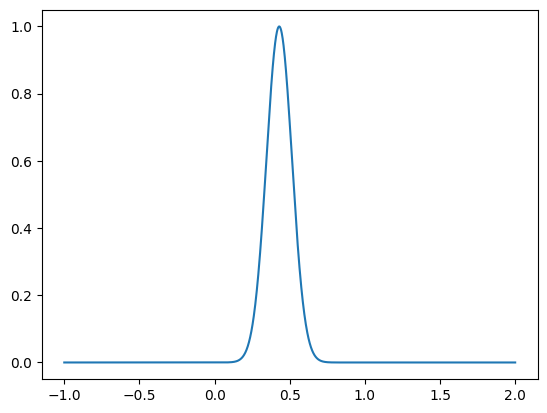

In [89]:
swave = np.cos(np.multiply(2*np.pi,np.multiply(sfreq,time))) #note how we don't have phase offset, or amplitude parameters but you could add those if you wanted
gausw = np.exp(4*np.log(2)*(time-gpeakt) / (np.power(gwidth,2))) # this is the example of a "silent error" demonstrated by cohen
gausw = np.exp(-4*np.log(2)*np.power(time-gpeakt,2) / (np.power(gwidth,2))) # this is the corrected example that he demonstrates
signal = swave * gausw


plt.plot(time, signal)
plt.figure()
plt.plot(time, swave)
plt.figure()
plt.plot(time, gausw)

Create the data and multiple channels plus nosie

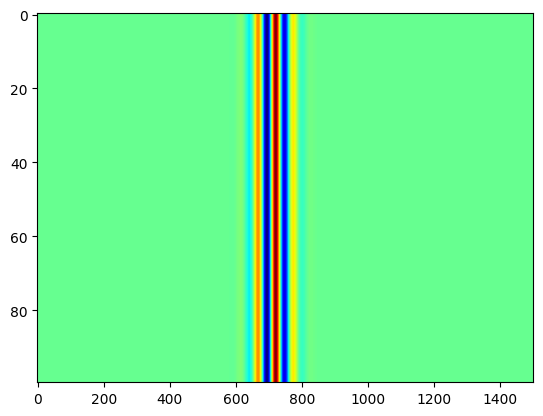

In [90]:
data = np.tile(signal,(ntrials,1)) # 1 is number of channels
fig,ax = plt.subplots()
ax.imshow(data, cmap="jet")
ax.set_aspect("auto")

Text(0.5, 1.0, 'average over trials')

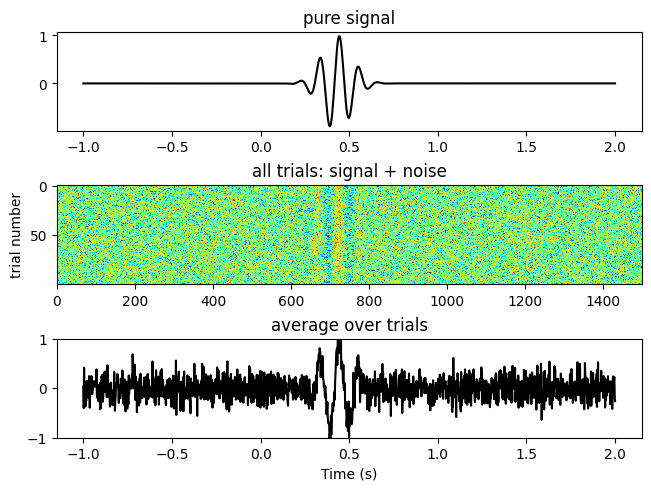

In [91]:
data = np.tile(signal,(ntrials,1)) # 1 is number of channels
data = data + (noiseamp * rng.standard_normal(size=(ntrials,len(time))))

fig,axes = plt.subplots(nrows=3, layout = "constrained")
axes[0].plot(time,signal, "k")
axes[0].set_title("pure signal")

axes[1].imshow(data, cmap="jet", vmin=-1*noiseamp*2, vmax = 1*noiseamp*2) #vmin and vmax correspond to the clim arg of matlab
axes[1].set_aspect("auto")
axes[1].set_ylabel("trial number")
axes[1].set_title("all trials: signal + noise")

axes[2].plot(time,np.mean(data, axis=0), "k")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylim((-1,1))
axes[2].set_title("average over trials")

Consider how averaging helps reveal the signal that is mixed in with the noise.

And now, let's examine ERPs with real data

In [116]:
# load in real data
laminar_data = loadmat('../data/v1_laminar.mat')
# inspect the data
print(laminar_data.keys())

# Extract variables from the loaded mat file
csd = laminar_data['csd']
timevec = laminar_data['timevec'].T # so that it is the right shape for later
srate = laminar_data['srate']

#inspect
print(csd.shape)
print(timevec.shape)

dict_keys(['__header__', '__version__', '__globals__', 'csd', 'timevec', 'srate'])
(16, 1527, 200)
(1527, 1)


Plot some of the time domain features

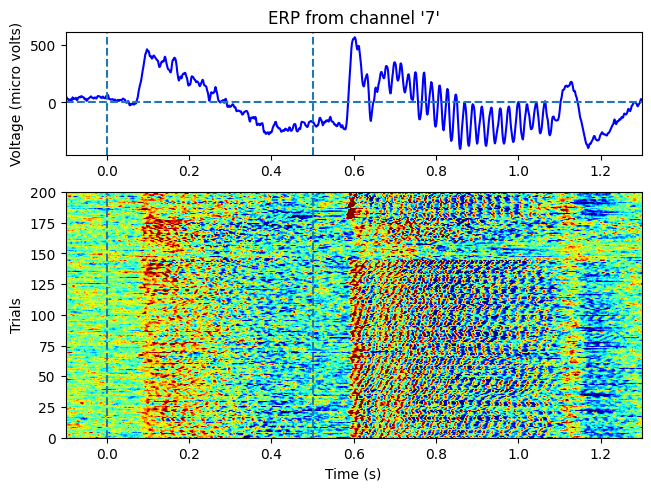

In [159]:
# pick a channel to plot
chan2plot = 7-1

#plot the erp from selected channel
fig,axes = plt.subplots(nrows=2, layout = "constrained", height_ratios=[1, 2])
axes[0].plot(timevec, np.mean(csd[chan2plot,:,:],1), 'b') # remember to subtract 1 to get the same channel as Cohen
axes[0].set_xlim(-0.1,1.3)
axes[0].set_title(f"ERP from channel '{chan2plot+1}'")
axes[0].set_ylabel("Voltage (micro volts)")
axes[0].axvline(x=0,linestyle='--') # first visual stimulus
axes[0].axvline(x=.5,linestyle = '--') # second visual stimulus
axes[0].axhline(y=0, linestyle= '--') #height of fwhm

#now plot all trials from this channel
axes[1].imshow(csd[chan2plot,:,:].T, cmap="jet", vmin= -1*1e3, vmax = 1*1e3, extent=[min(timevec),max(timevec),0,200]) # vlim is for the colours #extent lets us use the timevec here for the x axis
axes[1].set_xlim(-0.1,1.3)
axes[1].set_aspect("auto")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Trials")
axes[1].axvline(x=0,linestyle='--') # first visual stimulus
axes[1].axvline(x=.5,linestyle = '--') # second visual stimulus


Now we will look at the data for all the channels. It will use a contour plot.

(1527, 1)


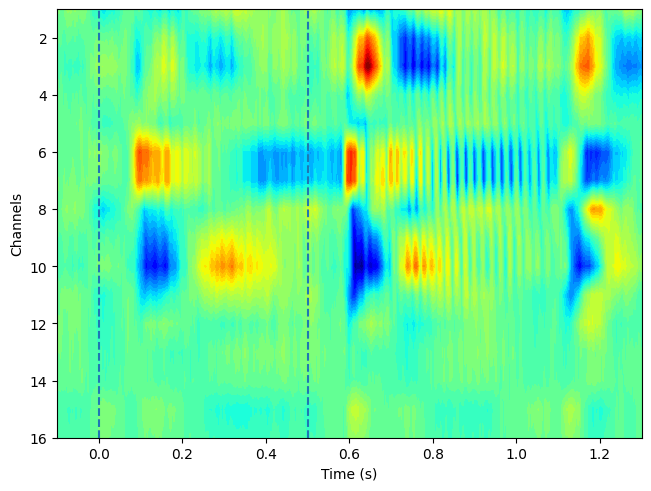

In [183]:
print(timevec.shape)

fig,ax = plt.subplots(nrows=1, layout = "constrained")
ax.contourf(np.squeeze(timevec), range(1,17), np.mean(csd,2), cmap='jet', levels=40)
ax.set_xlim(-0.1,1.3)
ax.invert_yaxis()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Channels")
ax.axvline(x=0,linestyle='--') # first visual stimulus
ax.axvline(x=.5,linestyle = '--') # second visual stimulus